In [36]:
import numpy as np
import matplotlib.pyplot as plt
import math

def model_function(x):
    return x

def polynomial_function(x,constants):
    #First c then bx then dx
    values = x
    ans = np.zeros(40)
    for deg,coff in enumerate(constants):
        
        ans += (values ** deg) * coff 
        
    return ans

def poly_function(x , constants):
    values = x
    ans = 0
    for deg,coff in enumerate(constants):
        ans += (values ** deg) * coff 
    return ans

def square_error(func_a, param , l , r):
    Err = 0
    for i in range(l,r):
        Err += (func_a(i) - poly_function(i , param)**2)
    return Err

def twick_values(coff, dev = 2):
    new_values = np.random.randn(len(coff)) / dev
    return coff + new_values

def Error_For_Reg(m,b, points, func):
    total_error = 0
    for i in range(len(points)):
        total_error += ( (func(points[i])) - (m * points[i] + b) ) ** 2
    return total_error

Error is:  10839803881.472843


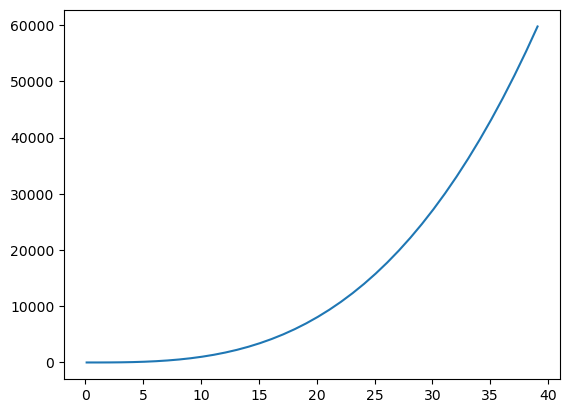

In [4]:
t = np.arange(0.1, 40, 1)
model_function(t)

plt.figure()
plt.plot(t, model_function(t))
print("Error is: ", square_error(model_function(t), polynomial_function(t, [1,2,10])))

In [4]:
n = 3

coff = np.random.randn(n)
final_coff = coff 
#coff = np.zeros(n)
print(coff)

best_error = 999999999999999999999999999999999999999
the_best_error = best_error
print("Running")

k = 10000
for j in range(10):

    final_coff = coff 
    
    best_error = 999999999999999999999999999999999999999
    
    print(j)
    coff = np.random.randn(n) * 0.01
    
    for i in range(1,k):
        if(k / i == 3):
            print("Third part is finished")
        if(k/i == 2):
            print("Half done")
        new_coff = twick_values(coff , 10)
        new_error = square_error(model_function(t), polynomial_function(t, new_coff))

        if new_error < best_error:
            best_error = new_error
            coff = new_coff
    print(best_error)
    if best_error < the_best_error:
        the_best_error = best_error
        
print("Final error: " , the_best_error)

[ 1.33972304  0.5260301  -0.52400974]
Running
0
Half done
89.84807591019658
1
Half done
91.23613248805398
2
Half done
92.38817675858905
3
Half done
81.06982583526543
4
Half done
86.38465654990917
5
Half done
102.0951020673814
6
Half done
98.50976967108306
7
Half done
89.01734435238691
8
Half done
97.3655768189846
9
Half done
94.52474777633253
Final error:  81.06982583526543


[ 0.32272557 -0.03165735  0.00058429]


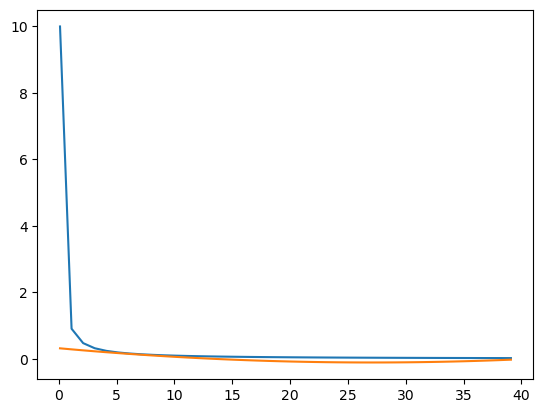

In [5]:
plt.figure()
print(coff)
plt.plot(t, model_function(t) )
plt.plot(t,polynomial_function(t, coff) )


In [56]:
def adjust_weights(weights, error,x, rate):
    for power,weight in enumerate(weights):
        weights[power] = weights[power] - (2 * error) * (power * x ** (power - 1)) * rate
    return weights
            

n = 2

coff = np.random.randn(n)
print(coff)

epochs = 10

for i in range(epochs):
    x = np.random.randint(40) + 1 
    error = 2 * (model_function(x) - poly_function(x , coff) ) 
    print(adjust_weights(coff, error, x , 0.0001))


[-1.05793415  0.01495286]
[-1.05793415 -6.23532079]
[ -1.05793415 -19.42275607]
[ -1.05793415 -32.77899052]
[ -1.05793415 -32.85746008]
[ -1.05793415 -42.0066868 ]
[ -1.05793415 -49.47437952]
[ -1.05793415 -64.5026645 ]
[ -1.05793415 -72.20431539]
[ -1.05793415 -80.85774517]
[  -1.05793415 -102.31606297]


[  -1.05793415 -102.31606297]


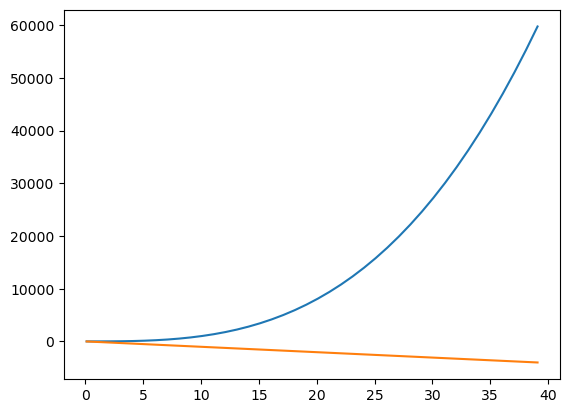

-451.047363 6.63
-716585477.7309203 -8335.984566128995
-1.1914440360593313e+36 -3.4060545722953824e+17


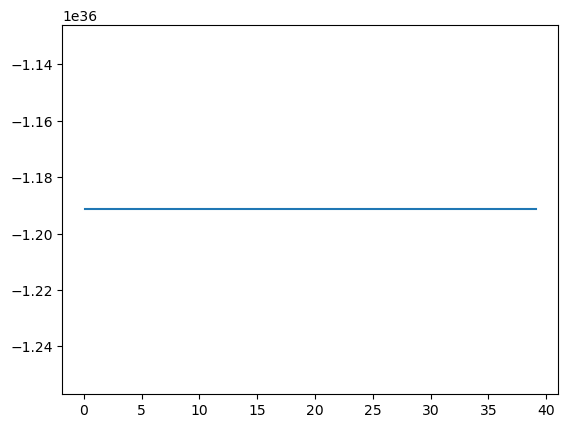

In [35]:
a = np.random.randint(5)
b = np.random.randint(5)

n = 3

lr = 0.01

for i in range(n):
    x = np.random.randint(40)
    #print(square_error(model_function , [a,b] , 1, 40 ) )
    #Adjust for b
    b = b - lr * -(2/40) * (square_error(model_function , [a,b] , 1, 40 ) ) * x
    a = a - lr * -(2/40) * (square_error(model_function , [a,b] , 1, 40 ) )
    
    print(a,b)

    
    
plt.figure()
plt.plot(t, model_function(t) )
plt.plot(t,polynomial_function(t, [a,b]) )
